# Seasonal extreme rainfall spatial distribution

This notebook keeps the plotting code editable in-place. The expensive seasonal diagnostics are cached in NetCDF by default, including seasonal mean rainfall, seasonal 95th and 99th percentile rainfall, and seasonal 850 hPa winds.

In [1]:
from pathlib import Path
import sys
CODE_DIR = Path('/work/mh1498/m301257/code_extreme_event')
SCRIPT_DIR = CODE_DIR / 'scripts'
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

from pathlib import Path
import os
import importlib.util
import sys
import warnings
import cmaps
os.environ.setdefault('MPLCONFIGDIR', '/tmp/m301257_matplotlib')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('NUMEXPR_NUM_THREADS', '1')

import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

warnings.filterwarnings('ignore', message='pyproj unable to set PROJ database path')

BASE_DIR = Path('/work/mh1498/m301257')

from Xianpumap import plot_western_pacific_basemap,_turn_off_cartopy_ticks

EASYXP_PATH = BASE_DIR / 'wave_tools' / 'easyxp.py'
_easyxp_spec = importlib.util.spec_from_file_location('easyxp_local', EASYXP_PATH)
if _easyxp_spec is None or _easyxp_spec.loader is None:
    raise ImportError(f'Cannot load quiver legend helper from {EASYXP_PATH}')
_easyxp_module = importlib.util.module_from_spec(_easyxp_spec)
_easyxp_spec.loader.exec_module(_easyxp_module)
simple_quiver_legend = _easyxp_module.simple_quiver_legend


Figure output directory: figures


In [2]:
CNTL_PR_PATH = BASE_DIR / 'processed_data_lat_30' / '2d_layers' / 'pr_cntl' / 'pr_2deg_interp.nc'
P4K_PR_PATH = BASE_DIR / 'processed_data_lat_30' / '2d_layers' / 'pr_p4k' / 'pr_2deg_interp.nc'


def load_precip_mm_day(path, lat_bounds=(-30, 30), wet_threshold=1.0):
    ds_in = xr.open_dataset(path)
    pr_da = ds_in['pr'] * 86400.0
    pr_da = pr_da.sel(lat=slice(*lat_bounds))
    pr_da = pr_da.where(pr_da > wet_threshold)
    pr_da.attrs['units'] = 'mm/day'
    pr_da.attrs['long_name'] = 'Precipitation'
    return pr_da


pr = load_precip_mm_day(CNTL_PR_PATH)
pr_p4k = load_precip_mm_day(P4K_PR_PATH)

print('CNTL precip:', pr)
print('P4K precip:', pr_p4k)


CNTL precip: <xarray.DataArray 'pr' (time: 5114, lat: 31, lon: 180)> Size: 228MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan, 1.6900456 ],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[1.90077424,        nan,        nan, ...,        nan,
                nan,        nan],
        [1.27632158,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,    

In [3]:
def percentile_pair(pr_da):
    p95_da = pr_da.quantile(0.95, dim='time', skipna=True).squeeze(drop=True)
    p99_da = pr_da.quantile(0.99, dim='time', skipna=True).squeeze(drop=True)
    return p95_da, p99_da


p95, p99 = percentile_pair(pr)
p95_p4k, p99_p4k = percentile_pair(pr_p4k)

p99_minus_p95 = p99 - p95
p99_minus_p95_p4k = p99_p4k - p95_p4k
p99_minus_p95_p4k_change = p99_minus_p95_p4k - p99_minus_p95

print('CNTL P99-P95')
print(p99_minus_p95)
print('P4K P99-P95')
print(p99_minus_p95_p4k)
print('P4K-CNTL change in P99-P95')
print(p99_minus_p95_p4k_change)


/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


CNTL P99-P95
<xarray.DataArray 'pr' (lat: 31, lon: 180)> Size: 45kB
array([[21.38304234, 10.11232681,  9.75406895, ..., 22.38763132,
        19.68922977, 16.12306309],
       [19.61163891, 11.50036472,  9.55267361, ..., 17.26914829,
        16.93988645, 13.0327617 ],
       [ 7.72695849,  9.24921827,  6.68936046, ..., 34.26842976,
        16.55654537, 14.40400622],
       ...,
       [ 0.65891486, 13.75401525,  5.86618463, ..., 12.64332715,
         6.04078595,  2.07423052],
       [ 2.92535769, 10.98077928,  4.53966507, ...,  4.3449864 ,
         4.65696317,  5.82834046],
       [ 1.06472969,  9.15215693, 16.85948753, ..., 26.51110668,
        11.74319115,  5.40830048]], shape=(31, 180))
Coordinates:
  * lat      (lat) float64 248B -30.0 -28.0 -26.0 -24.0 ... 24.0 26.0 28.0 30.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
P4K P99-P95
<xarray.DataArray 'pr' (lat: 31, lon: 180)> Size: 45kB
array([[2.58846474e+01, 2.02053452e+01, 1.52593746e+01, ...,
  

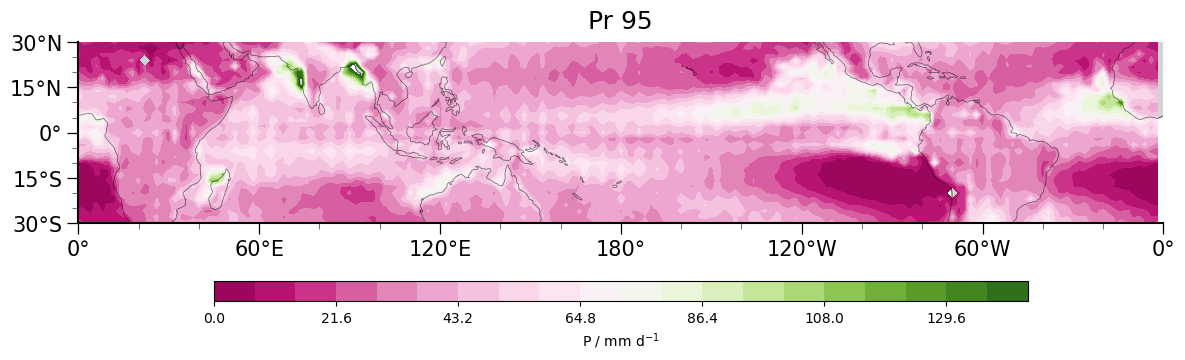

In [4]:
WESTERN_PACIFIC_EXTENT = [0, 360, -30, 30]

fig, ax = plot_western_pacific_basemap(
    extent=WESTERN_PACIFIC_EXTENT,
    central_lon=180,
    figsize=(14, 7.5),
    title="",
    use_geocat=True,
    show_labels=True,
    add_reference_lines=False,
    land_facecolor="lightgray",
    coastline_color="gray",
    basename="western_pacific_basemap_provided_style",
    save=False,
)
im = ax.contourf(
    p95.lon.values, p95.lat.values, p95.values,
    levels=np.linspace(0, 144, 21),
    cmap='PiYG',
    vmin=0, vmax=144,
    transform=ccrs.PlateCarree(),
    extend='neither',
)

_turn_off_cartopy_ticks(ax)

ax.set_title('Pr 95', pad=10, fontsize=18)

cbar1 = fig.colorbar(im, ax=ax, orientation='horizontal',
                     pad=0.1, shrink=0.75, aspect=40, label=r'P / mm d$^{-1}$')

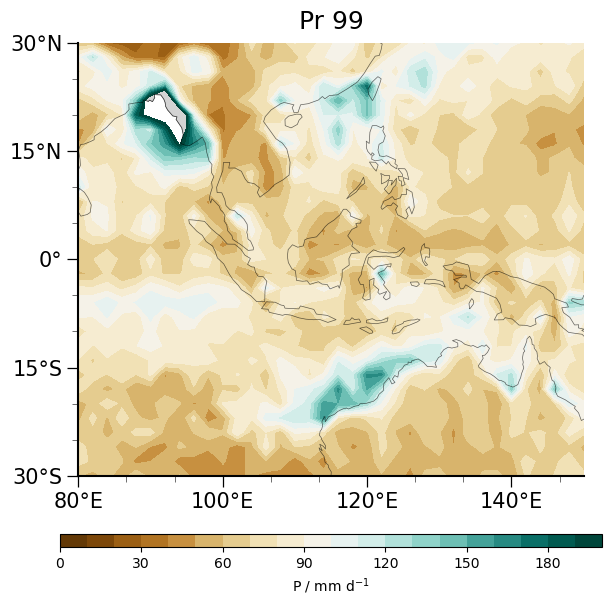

In [5]:

fig, ax = plot_western_pacific_basemap(
    extent= [80, 150, -30, 30],
    central_lon=180,
    figsize=(14, 7.5),
    title="",
    use_geocat=True,
    show_labels=True,
    add_reference_lines=False,
    land_facecolor="lightgray",
    coastline_color="gray",
    basename="western_pacific_basemap_provided_style",
    save=False,
)
im = ax.contourf(
    p99.lon.values, p99.lat.values, p99.values,
    levels=np.linspace(0, 200, 21),
    cmap=cmaps.MPL_BrBG,
    vmin=0, vmax=200,
    transform=ccrs.PlateCarree(),
    extend='neither',
)

_turn_off_cartopy_ticks(ax)

ax.set_title('Pr 99', pad=10, fontsize=18)

cbar1 = fig.colorbar(im, ax=ax, orientation='horizontal',
                     pad=0.1, shrink=0.5, aspect=40, label=r'P / mm d$^{-1}$')

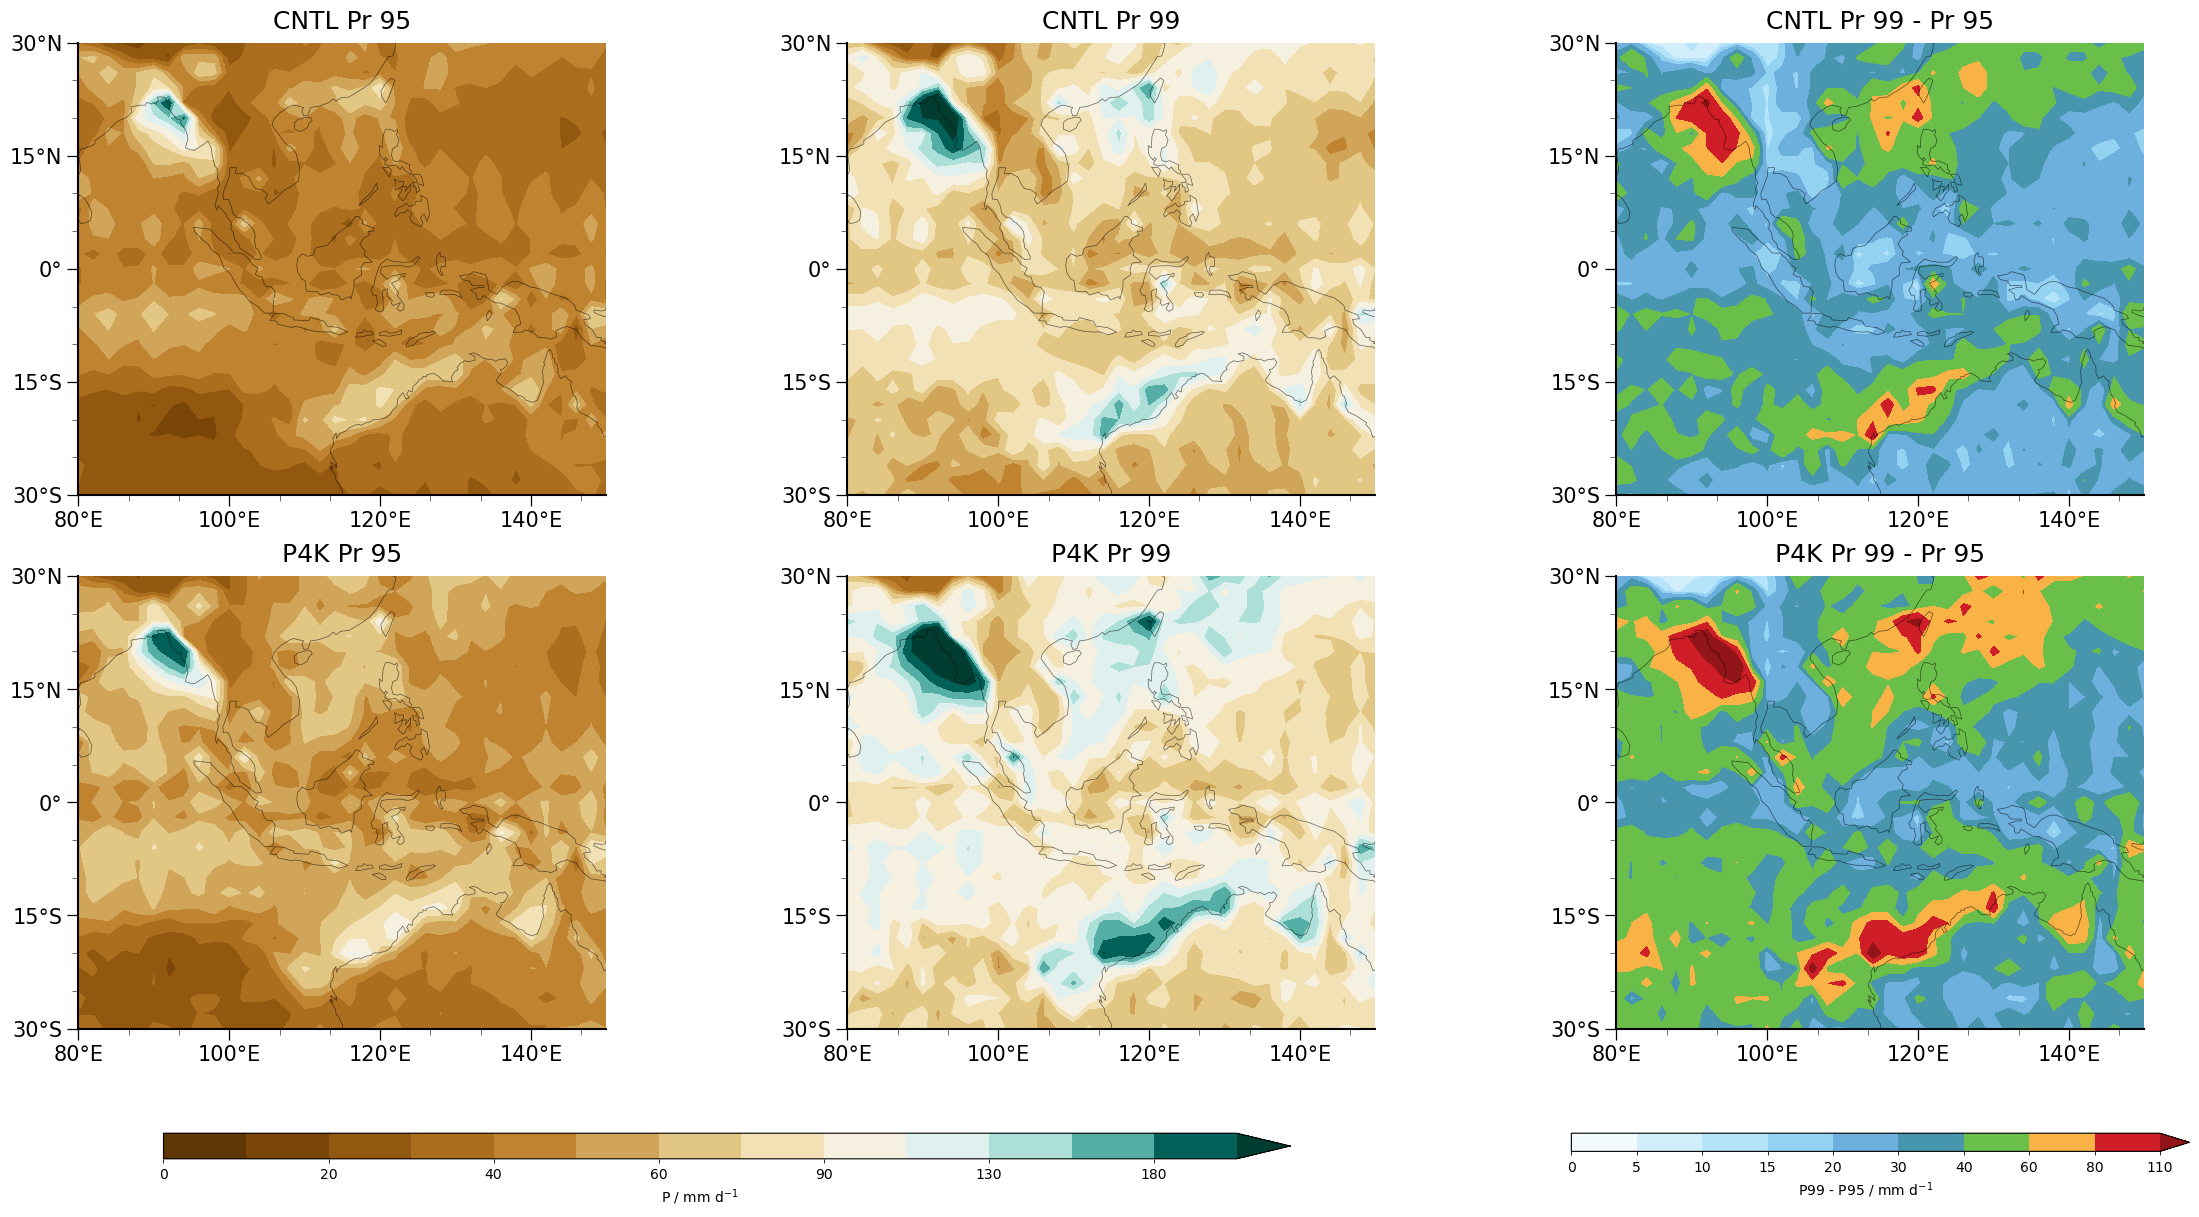

In [6]:
rain_levels = np.array([0, 10, 20, 30, 40, 50, 60, 75, 90, 110, 130, 150, 180, 220])
diff_levels = np.array([0, 5, 10, 15, 20, 30, 40, 60, 80, 110])
change_levels = np.array([-60, -40, -25, -15, -8, -3, 3, 8, 15, 25, 40, 60])

plot_extent = [80, 150, -30, 30]

fig, axes = plt.subplots(
    2, 3,
    figsize=(23, 12.0),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
    constrained_layout=True,
)

plot_specs = [
    (p95, 'CNTL Pr 95', rain_levels, cmaps.MPL_BrBG, 'rain'),
    (p99, 'CNTL Pr 99', rain_levels, cmaps.MPL_BrBG, 'rain'),
    (p99_minus_p95, 'CNTL Pr 99 - Pr 95', diff_levels, cmaps.WhiteBlueGreenYellowRed, 'diff'),
    (p95_p4k, 'P4K Pr 95', rain_levels, cmaps.MPL_BrBG, 'rain'),
    (p99_p4k, 'P4K Pr 99', rain_levels, cmaps.MPL_BrBG, 'rain'),
    (p99_minus_p95_p4k, 'P4K Pr 99 - Pr 95', diff_levels, cmaps.WhiteBlueGreenYellowRed, 'diff'),
]

mappables = {}
for ax, (da, title, levels, cmap, group) in zip(axes.flat, plot_specs):
    _, ax = plot_western_pacific_basemap(
        extent=plot_extent,
        central_lon=180,
        figsize=(14, 7.5),
        title='',
        use_geocat=True,
        show_labels=True,
        add_reference_lines=False,
        land_facecolor='lightgray',
        coastline_color='gray',
        basename='western_pacific_basemap_provided_style',
        save=False,
        fig=fig,
        ax=ax,
    )

    im = ax.contourf(
        da.lon.values,
        da.lat.values,
        da.values,
        levels=levels,
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        extend='max',
    )
    mappables[group] = im

    _turn_off_cartopy_ticks(ax)
    ax.set_title(title, pad=10, fontsize=18)

cbar_rain = fig.colorbar(
    mappables['rain'],
    ax=axes[:, :2].ravel().tolist(),
    orientation='horizontal',
    pad=0.06,
    shrink=0.74,
    aspect=44,
    ticks=rain_levels[::2],
    label=r'P / mm d$^{-1}$',
)

cbar_diff = fig.colorbar(
    mappables['diff'],
    ax=axes[:, 2].ravel().tolist(),
    orientation='horizontal',
    pad=0.06,
    shrink=0.82,
    aspect=34,
    ticks=diff_levels,
    label=r'P99 - P95 / mm d$^{-1}$',
)

for cbar in (cbar_rain, cbar_diff):
    cbar.ax.tick_params(labelsize=10, length=3, width=0.6)

plt.show()


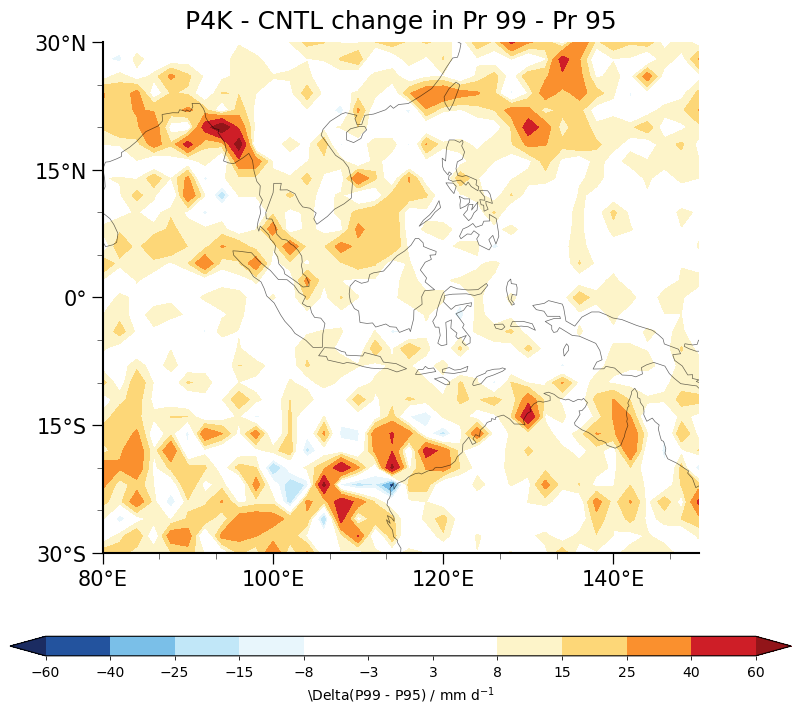

In [7]:
fig, ax = plt.subplots(
    1, 1,
    figsize=(10.5, 7.0),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
    constrained_layout=True,
)

_, ax = plot_western_pacific_basemap(
    extent=plot_extent,
    central_lon=180,
    figsize=(10.5, 7.0),
    title='',
    use_geocat=True,
    show_labels=True,
    add_reference_lines=False,
    land_facecolor='lightgray',
    coastline_color='gray',
    basename='western_pacific_basemap_provided_style',
    save=False,
    fig=fig,
    ax=ax,
)

im = ax.contourf(
    p99_minus_p95_p4k_change.lon.values,
    p99_minus_p95_p4k_change.lat.values,
    p99_minus_p95_p4k_change.values,
    levels=change_levels,
    cmap=cmaps.BlueWhiteOrangeRed,
    transform=ccrs.PlateCarree(),
    extend='both',
)

_turn_off_cartopy_ticks(ax)
ax.set_title('P4K - CNTL change in Pr 99 - Pr 95', pad=10, fontsize=18)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation='horizontal',
    pad=0.08,
    shrink=0.75,
    aspect=40,
    ticks=change_levels,
    label=r'\Delta(P99 - P95) / mm d$^{-1}$',
)
cbar.ax.tick_params(labelsize=10, length=3, width=0.6)

plt.show()


## Seasonal extreme rainfall contribution

The next cells separate two related diagnostics: seasonal percentile intensity (`Pr95`, `Pr99`, and `Pr99-Pr95`) and the seasonal contribution to the long-term mean of extreme rainfall. The contribution metric uses the all-time percentile threshold at each grid point, sets non-extreme days to zero, then averages by season.


In [8]:
SEASON_ORDER = ['DJF', 'MAM', 'JJA', 'SON']
SEASON_COLORS = ['#3B7DDD', '#4DAF4A', '#F28E2B', '#8E63B6']
SEASON_CMAP = ListedColormap(SEASON_COLORS)
SEASON_NORM = BoundaryNorm(np.arange(-0.5, len(SEASON_ORDER) + 0.5, 1), SEASON_CMAP.N)

analysis_extent = globals().get('plot_extent', [80, 150, -30, 30])


def _available_seasons_for_time(pr_da):
    values = set(np.asarray(pr_da['time'].dt.season.values).tolist())
    return [season for season in SEASON_ORDER if season in values]


def _concat_seasonal(pieces, seasons, name=None):
    out = xr.concat(pieces, dim=xr.IndexVariable('season', seasons))
    if name is not None:
        out.name = name
    return out


def seasonal_percentiles(pr_da):
    seasons = _available_seasons_for_time(pr_da)
    p95_pieces = []
    p99_pieces = []
    for season in seasons:
        season_da = pr_da.where(pr_da['time'].dt.season == season, drop=True)
        p95_pieces.append(season_da.quantile(0.95, dim='time', skipna=True).squeeze(drop=True))
        p99_pieces.append(season_da.quantile(0.99, dim='time', skipna=True).squeeze(drop=True))
    p95_season = _concat_seasonal(p95_pieces, seasons, name='seasonal_p95')
    p99_season = _concat_seasonal(p99_pieces, seasons, name='seasonal_p99')
    return p95_season, p99_season, p99_season - p95_season


def seasonal_extreme_contribution(pr_da, threshold_da):
    seasons = _available_seasons_for_time(pr_da)
    extreme_daily_amount = pr_da.where(pr_da >= threshold_da, 0.0)
    pieces = []
    for season in seasons:
        season_extreme = extreme_daily_amount.where(pr_da['time'].dt.season == season, drop=True)
        pieces.append(season_extreme.mean('time', skipna=True).squeeze(drop=True))
    return _concat_seasonal(pieces, seasons, name='seasonal_p99_contribution')

def dominant_season_index(seasonal_da):
    valid = seasonal_da.notnull().any('season')
    dominant = seasonal_da.fillna(-np.inf).argmax('season')
    return dominant.where(valid)


def regional_seasonal_mean(seasonal_da, extent=analysis_extent):
    region = seasonal_da.sel(lon=slice(extent[0], extent[1]), lat=slice(extent[2], extent[3]))
    weights = np.cos(np.deg2rad(region.lat))
    return region.weighted(weights).mean(('lat', 'lon'), skipna=True)


seasonal_p95, seasonal_p99, seasonal_p99_minus_p95 = seasonal_percentiles(pr)
seasonal_p95_p4k, seasonal_p99_p4k, seasonal_p99_minus_p95_p4k = seasonal_percentiles(pr_p4k)

seasonal_p99_change = seasonal_p99_p4k - seasonal_p99
seasonal_p99_minus_p95_change = seasonal_p99_minus_p95_p4k - seasonal_p99_minus_p95

p99_contribution = seasonal_extreme_contribution(pr, p99)
p99_contribution_p4k = seasonal_extreme_contribution(pr_p4k, p99_p4k)
p99_contribution_change = p99_contribution_p4k - p99_contribution

p99_contribution_total = p99_contribution.sum('season')
p99_contribution_total_p4k = p99_contribution_p4k.sum('season')
p99_contribution_fraction = 100.0 * p99_contribution / p99_contribution_total.where(p99_contribution_total > 0)
p99_contribution_fraction_p4k = 100.0 * p99_contribution_p4k / p99_contribution_total_p4k.where(p99_contribution_total_p4k > 0)
p99_contribution_fraction_change = p99_contribution_fraction_p4k - p99_contribution_fraction

p99_dominant_season = dominant_season_index(p99_contribution)
p99_dominant_season_p4k = dominant_season_index(p99_contribution_p4k)
valid_dominant_season = p99_dominant_season.notnull() & p99_dominant_season_p4k.notnull()
p99_dominant_season_changed = (p99_dominant_season_p4k != p99_dominant_season).where(valid_dominant_season)

summary_cntl = regional_seasonal_mean(p99_contribution).to_series().rename('CNTL P99 contribution')
summary_p4k = regional_seasonal_mean(p99_contribution_p4k).to_series().rename('P4K P99 contribution')
summary_change = regional_seasonal_mean(p99_contribution_change).to_series().rename('P4K-CNTL')
seasonal_contribution_summary = xr.merge([
    summary_cntl.to_xarray(),
    summary_p4k.to_xarray(),
    summary_change.to_xarray(),
]).to_dataframe()

print(seasonal_contribution_summary)
print('CNTL dominant regional season:', seasonal_contribution_summary['CNTL P99 contribution'].idxmax())
print('P4K dominant regional season:', seasonal_contribution_summary['P4K P99 contribution'].idxmax())


/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fn

        CNTL P99 contribution  P4K P99 contribution  P4K-CNTL
season                                                       
DJF                  0.428204              0.568481  0.140277
MAM                  0.340591              0.381117  0.040526
JJA                  0.441407              0.574740  0.133333
SON                  0.299873              0.366032  0.066159
CNTL dominant regional season: JJA
P4K dominant regional season: JJA


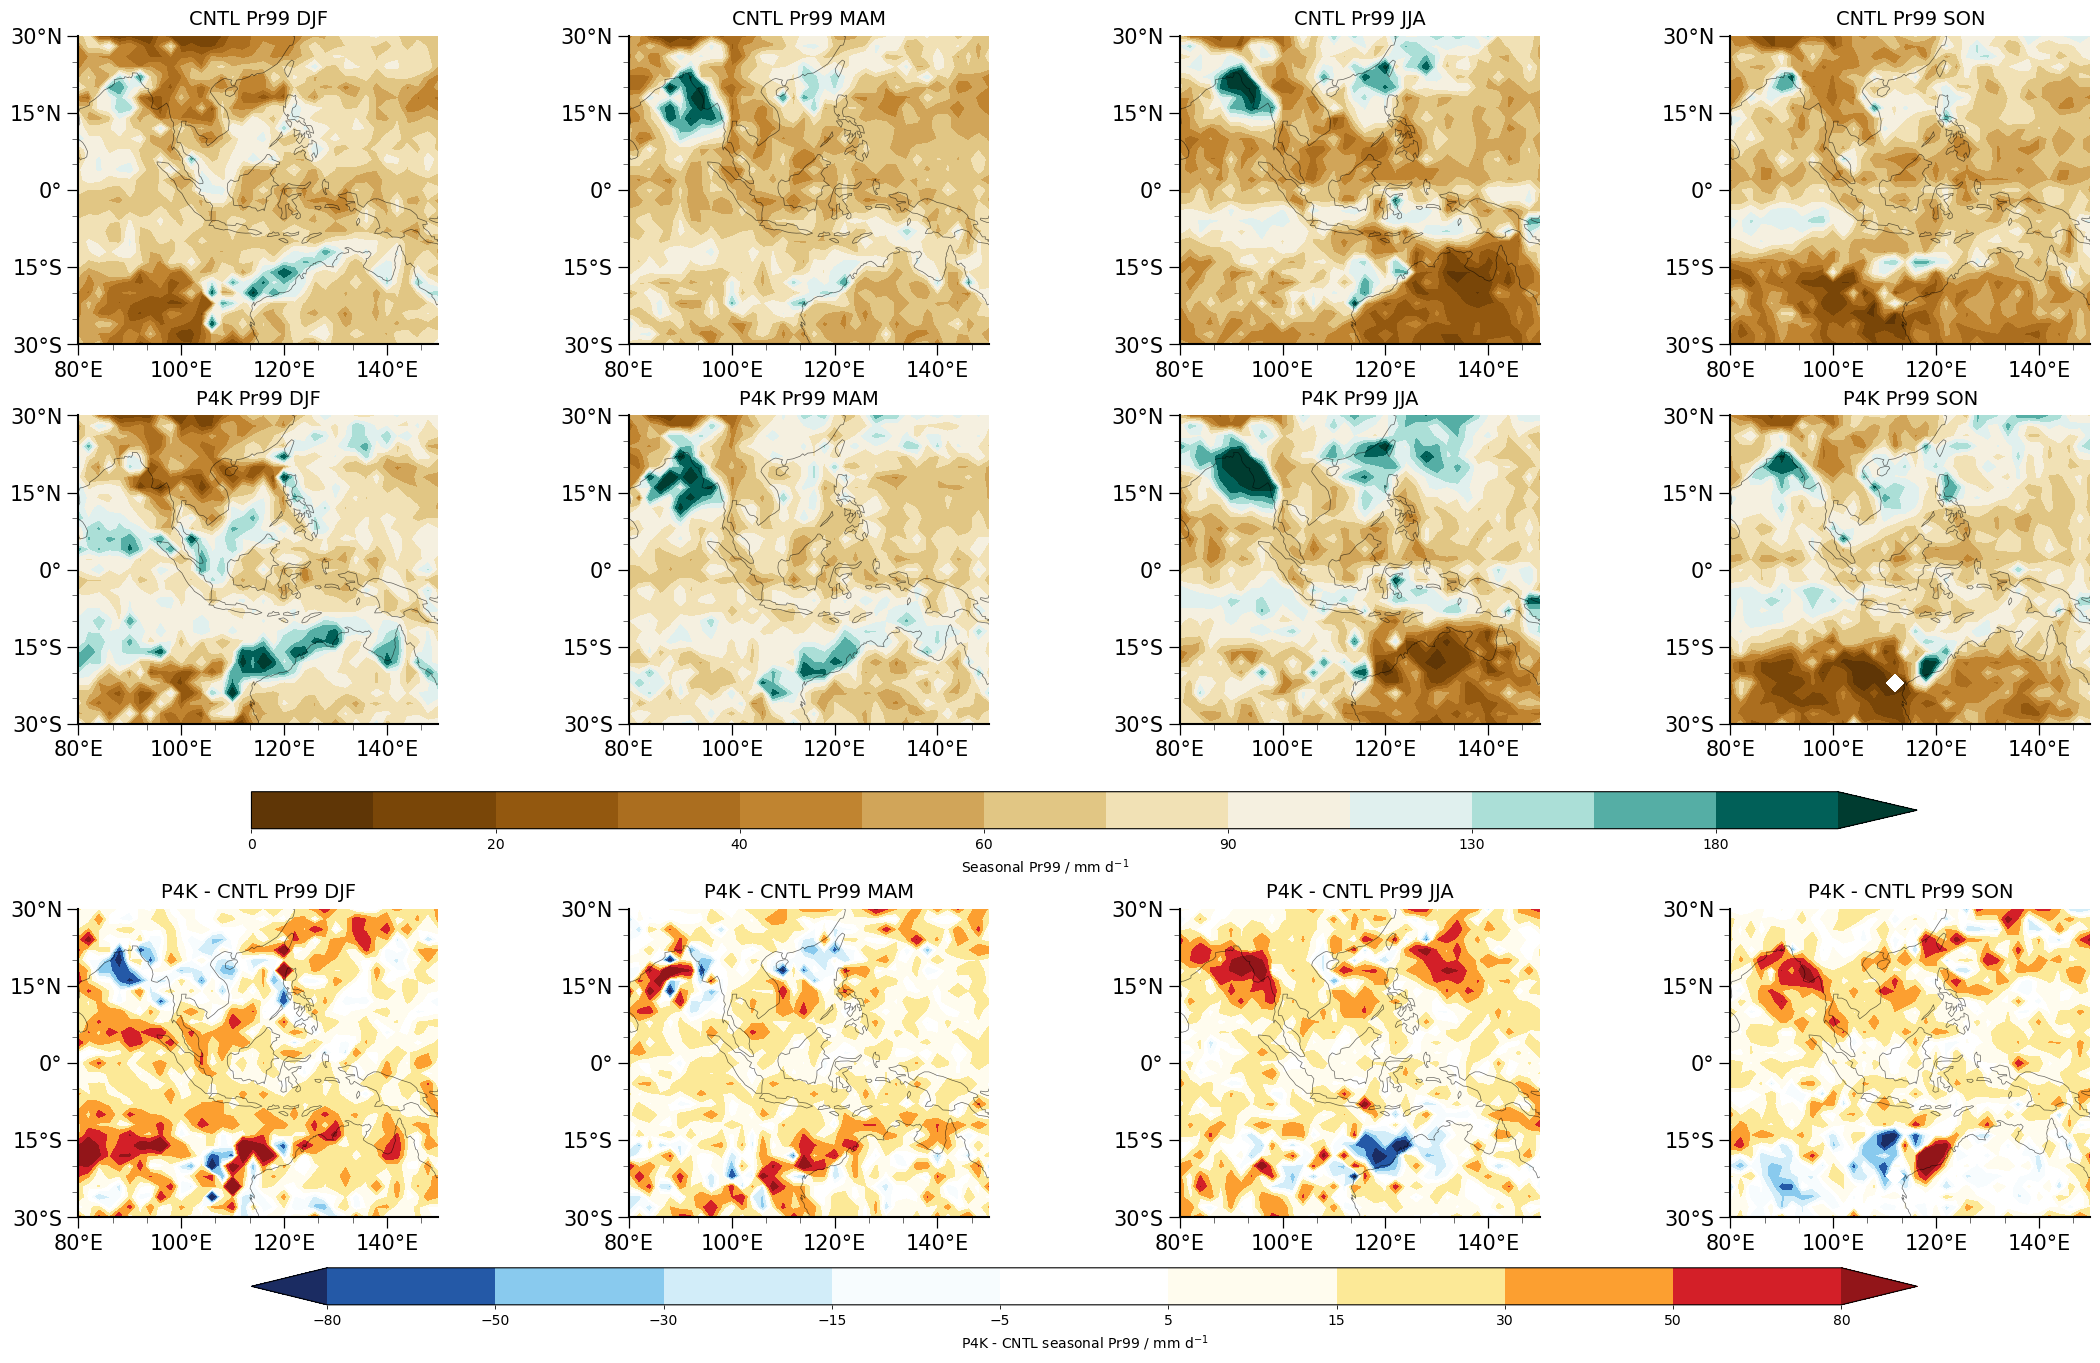

In [9]:
seasonal_rain_levels = np.array([0, 10, 20, 30, 40, 50, 60, 75, 90, 110, 130, 150, 180, 220])
seasonal_change_levels = np.array([-80, -50, -30, -15, -5, 5, 15, 30, 50, 80])

fig, axes = plt.subplots(
    3, 4,
    figsize=(22, 13.5),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
    constrained_layout=True,
)

for col, season in enumerate(SEASON_ORDER):
    for row, (da, title_prefix, levels, cmap, extend) in enumerate([
        (seasonal_p99.sel(season=season), 'CNTL Pr99', seasonal_rain_levels, cmaps.MPL_BrBG, 'max'),
        (seasonal_p99_p4k.sel(season=season), 'P4K Pr99', seasonal_rain_levels, cmaps.MPL_BrBG, 'max'),
        (seasonal_p99_change.sel(season=season), 'P4K - CNTL Pr99', seasonal_change_levels, cmaps.BlueWhiteOrangeRed, 'both'),
    ]):
        ax = axes[row, col]
        _, ax = plot_western_pacific_basemap(
            extent=analysis_extent,
            central_lon=180,
            figsize=(5.5, 4.0),
            title='',
            use_geocat=True,
            show_labels=True,
            add_reference_lines=False,
            land_facecolor='lightgray',
            coastline_color='gray',
            basename='western_pacific_basemap_provided_style',
            save=False,
            fig=fig,
            ax=ax,
        )
        im = ax.contourf(
            da.lon.values,
            da.lat.values,
            da.values,
            levels=levels,
            cmap=cmap,
            transform=ccrs.PlateCarree(),
            extend=extend,
        )
        _turn_off_cartopy_ticks(ax)
        ax.set_title(f'{title_prefix} {season}', pad=8, fontsize=14)
        if row == 0:
            rain_im = im
        if row == 2:
            change_im = im

cbar_rain = fig.colorbar(
    rain_im,
    ax=axes[:2, :].ravel().tolist(),
    orientation='horizontal',
    pad=0.04,
    shrink=0.76,
    aspect=45,
    ticks=seasonal_rain_levels[::2],
    label=r'Seasonal Pr99 / mm d$^{-1}$',
)
cbar_change = fig.colorbar(
    change_im,
    ax=axes[2, :].ravel().tolist(),
    orientation='horizontal',
    pad=0.04,
    shrink=0.76,
    aspect=45,
    ticks=seasonal_change_levels,
    label=r'P4K - CNTL seasonal Pr99 / mm d$^{-1}$',
)
for cbar in (cbar_rain, cbar_change):
    cbar.ax.tick_params(labelsize=10, length=3, width=0.6)

plt.show()


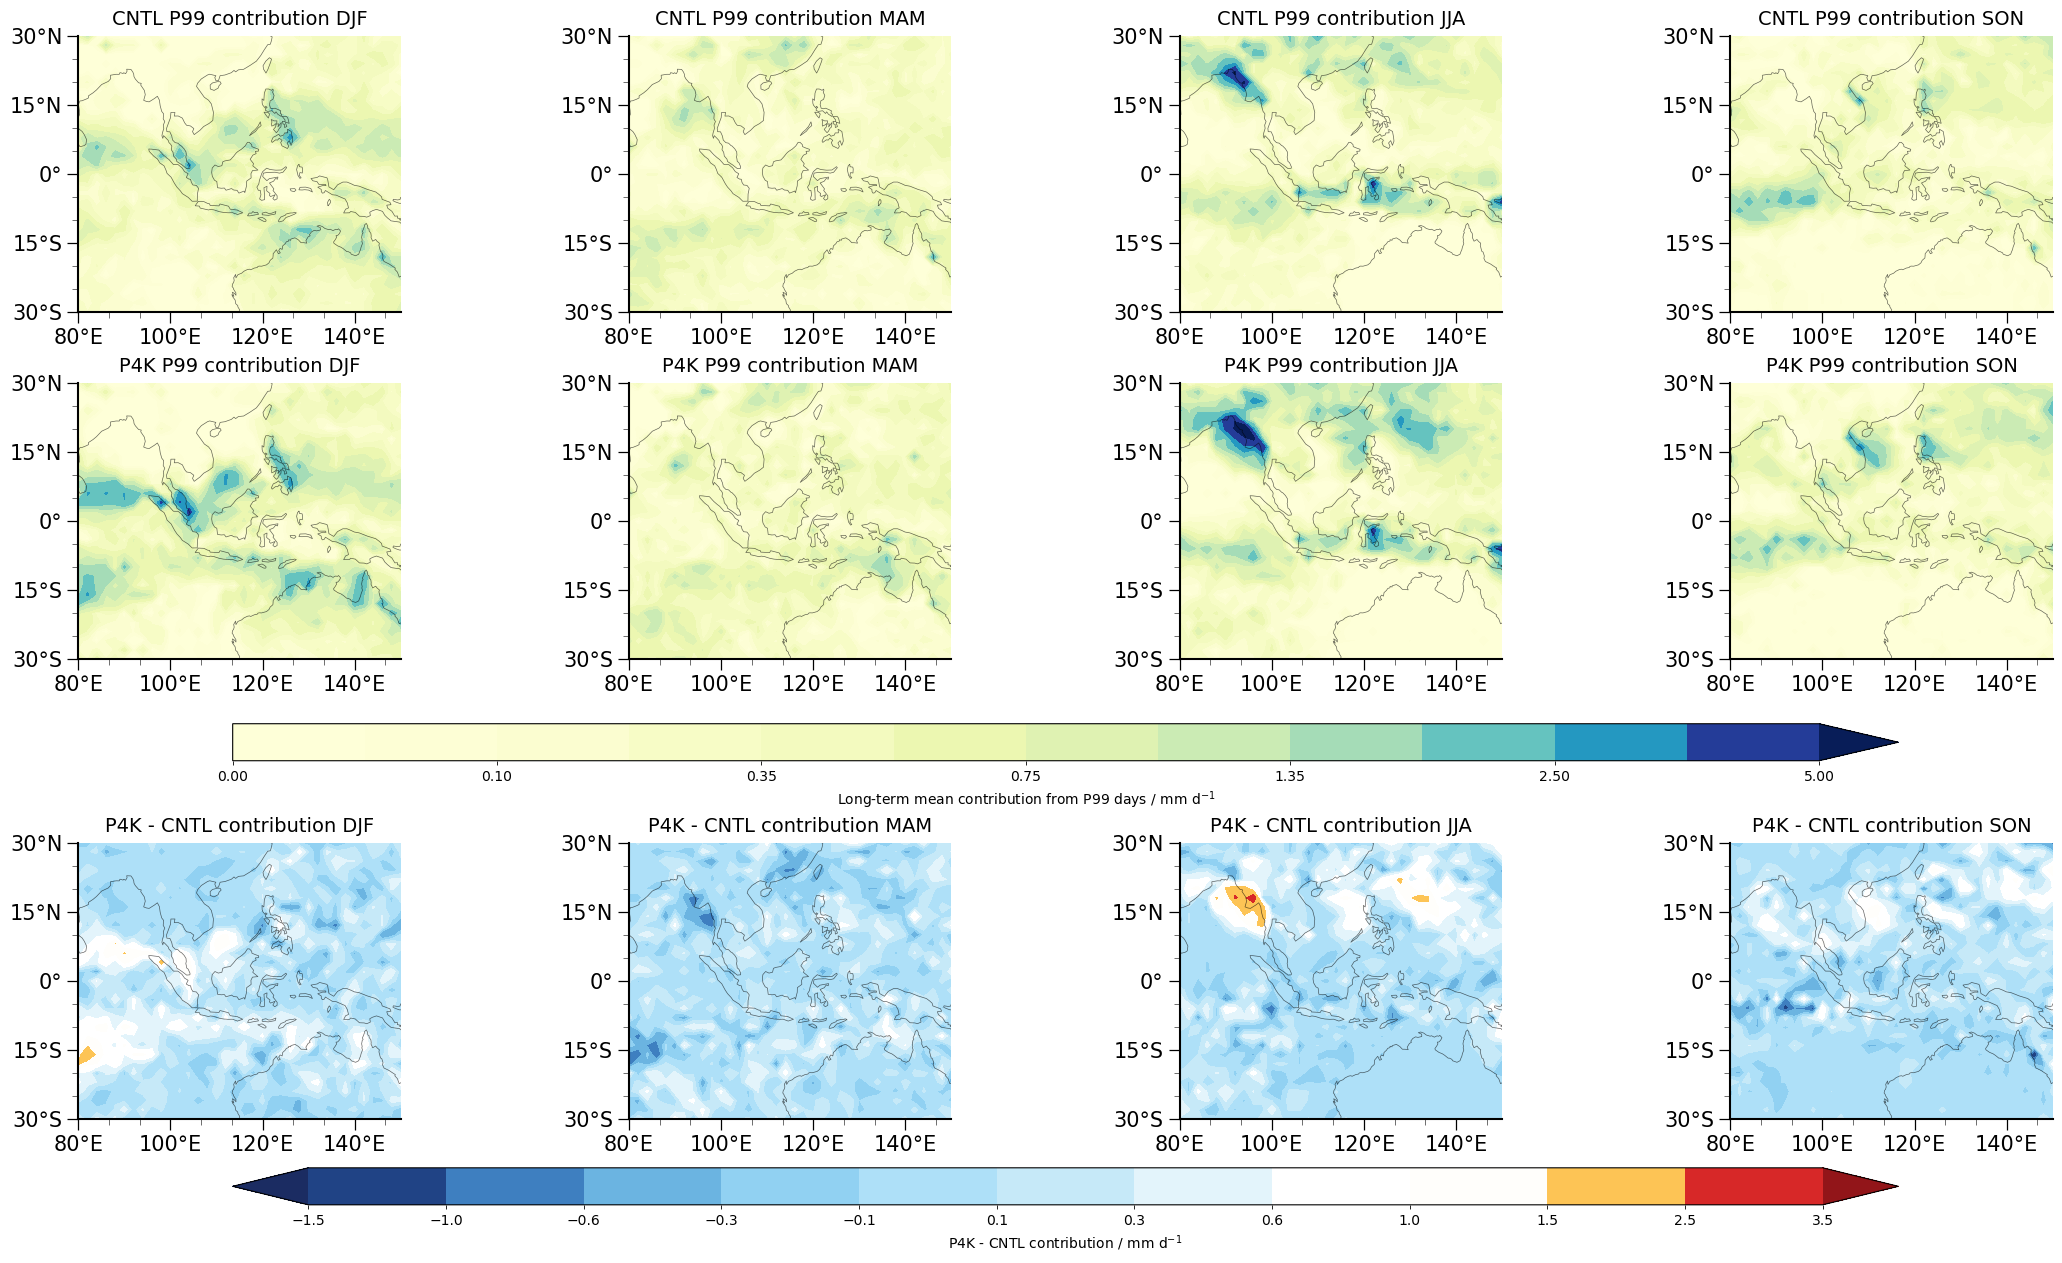

In [10]:
contribution_levels = np.array([0, 0.05, 0.10, 0.20, 0.35, 0.50, 0.75, 1.00, 1.35, 1.75, 2.50, 3.50, 5.00])
contribution_change_levels = np.array([-1.5, -1.0, -0.6, -0.3, -0.1, 0.1, 0.3, 0.6, 1.0, 1.5, 2.5, 3.5])

fig, axes = plt.subplots(
    3, 4,
    figsize=(22, 12.5),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
    constrained_layout=True,
)

for col, season in enumerate(SEASON_ORDER):
    panel_specs = [
        (p99_contribution.sel(season=season), 'CNTL P99 contribution', contribution_levels, cmaps.MPL_YlGnBu, 'max', 'absolute'),
        (p99_contribution_p4k.sel(season=season), 'P4K P99 contribution', contribution_levels, cmaps.MPL_YlGnBu, 'max', 'absolute'),
        (p99_contribution_change.sel(season=season), 'P4K - CNTL contribution', contribution_change_levels, cmaps.BlueWhiteOrangeRed, 'both', 'change'),
    ]
    for row, (da, title_prefix, levels, cmap, extend, group) in enumerate(panel_specs):
        ax = axes[row, col]
        _, ax = plot_western_pacific_basemap(
            extent=analysis_extent,
            central_lon=180,
            figsize=(5.5, 4.0),
            title='',
            use_geocat=True,
            show_labels=True,
            add_reference_lines=False,
            land_facecolor='lightgray',
            coastline_color='gray',
            basename='western_pacific_basemap_provided_style',
            save=False,
            fig=fig,
            ax=ax,
        )
        im = ax.contourf(
            da.lon.values,
            da.lat.values,
            da.values,
            levels=levels,
            cmap=cmap,
            transform=ccrs.PlateCarree(),
            extend=extend,
        )
        _turn_off_cartopy_ticks(ax)
        ax.set_title(f'{title_prefix} {season}', pad=8, fontsize=14)
        if group == 'absolute':
            absolute_im = im
        else:
            change_im = im

cbar_abs = fig.colorbar(
    absolute_im,
    ax=axes[:2, :].ravel().tolist(),
    orientation='horizontal',
    pad=0.04,
    shrink=0.76,
    aspect=45,
    ticks=contribution_levels[::2],
    label=r'Long-term mean contribution from P99 days / mm d$^{-1}$',
)
cbar_change = fig.colorbar(
    change_im,
    ax=axes[2, :].ravel().tolist(),
    orientation='horizontal',
    pad=0.04,
    shrink=0.76,
    aspect=45,
    ticks=contribution_change_levels,
    label=r'P4K - CNTL contribution / mm d$^{-1}$',
)
for cbar in (cbar_abs, cbar_change):
    cbar.ax.tick_params(labelsize=10, length=3, width=0.6)

plt.show()


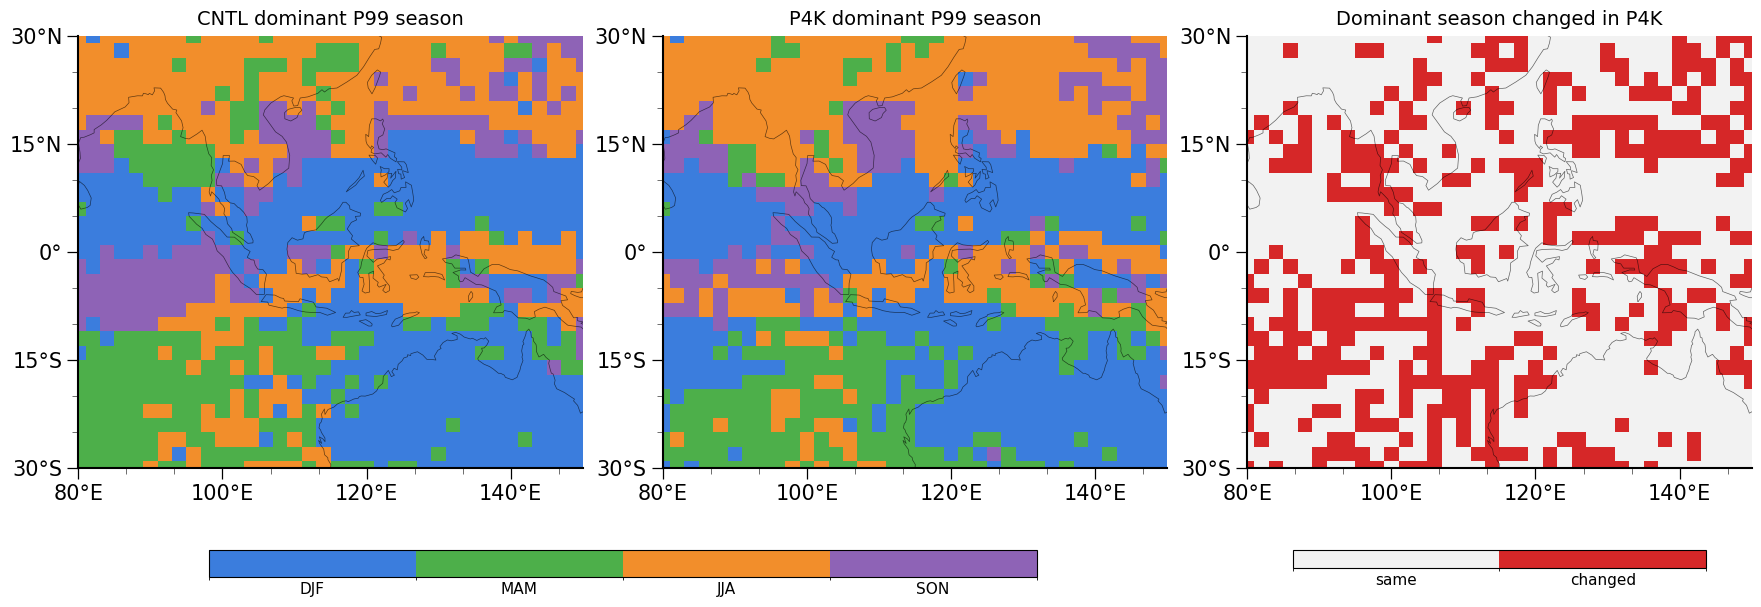

In [11]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(17.5, 6.2),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
    constrained_layout=True,
)

dominant_specs = [
    (p99_dominant_season, 'CNTL dominant P99 season', SEASON_CMAP, SEASON_NORM, None),
    (p99_dominant_season_p4k, 'P4K dominant P99 season', SEASON_CMAP, SEASON_NORM, None),
    (p99_dominant_season_changed.astype(float), 'Dominant season changed in P4K', ListedColormap(['#F2F2F2', '#D62728']), BoundaryNorm([-0.5, 0.5, 1.5], 2), ['same', 'changed']),
]

for ax, (da, title, cmap, norm, labels) in zip(axes, dominant_specs):
    _, ax = plot_western_pacific_basemap(
        extent=analysis_extent,
        central_lon=180,
        figsize=(5.8, 4.8),
        title='',
        use_geocat=True,
        show_labels=True,
        add_reference_lines=False,
        land_facecolor='lightgray',
        coastline_color='gray',
        basename='western_pacific_basemap_provided_style',
        save=False,
        fig=fig,
        ax=ax,
    )
    im = ax.pcolormesh(
        da.lon.values,
        da.lat.values,
        da.values,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        shading='auto',
    )
    _turn_off_cartopy_ticks(ax)
    ax.set_title(title, pad=8, fontsize=14)
    if labels is None:
        season_im = im
    else:
        changed_im = im

cbar_season = fig.colorbar(
    season_im,
    ax=axes[:2].ravel().tolist(),
    orientation='horizontal',
    pad=0.08,
    shrink=0.76,
    aspect=30,
    ticks=np.arange(len(SEASON_ORDER)),
)
cbar_season.ax.set_xticklabels(SEASON_ORDER)
cbar_season.ax.tick_params(labelsize=11, length=0)

cbar_changed = fig.colorbar(
    changed_im,
    ax=axes[2],
    orientation='horizontal',
    pad=0.08,
    shrink=0.82,
    aspect=22,
    ticks=[0, 1],
)
cbar_changed.ax.set_xticklabels(['same', 'changed'])
cbar_changed.ax.tick_params(labelsize=11, length=0)

plt.show()


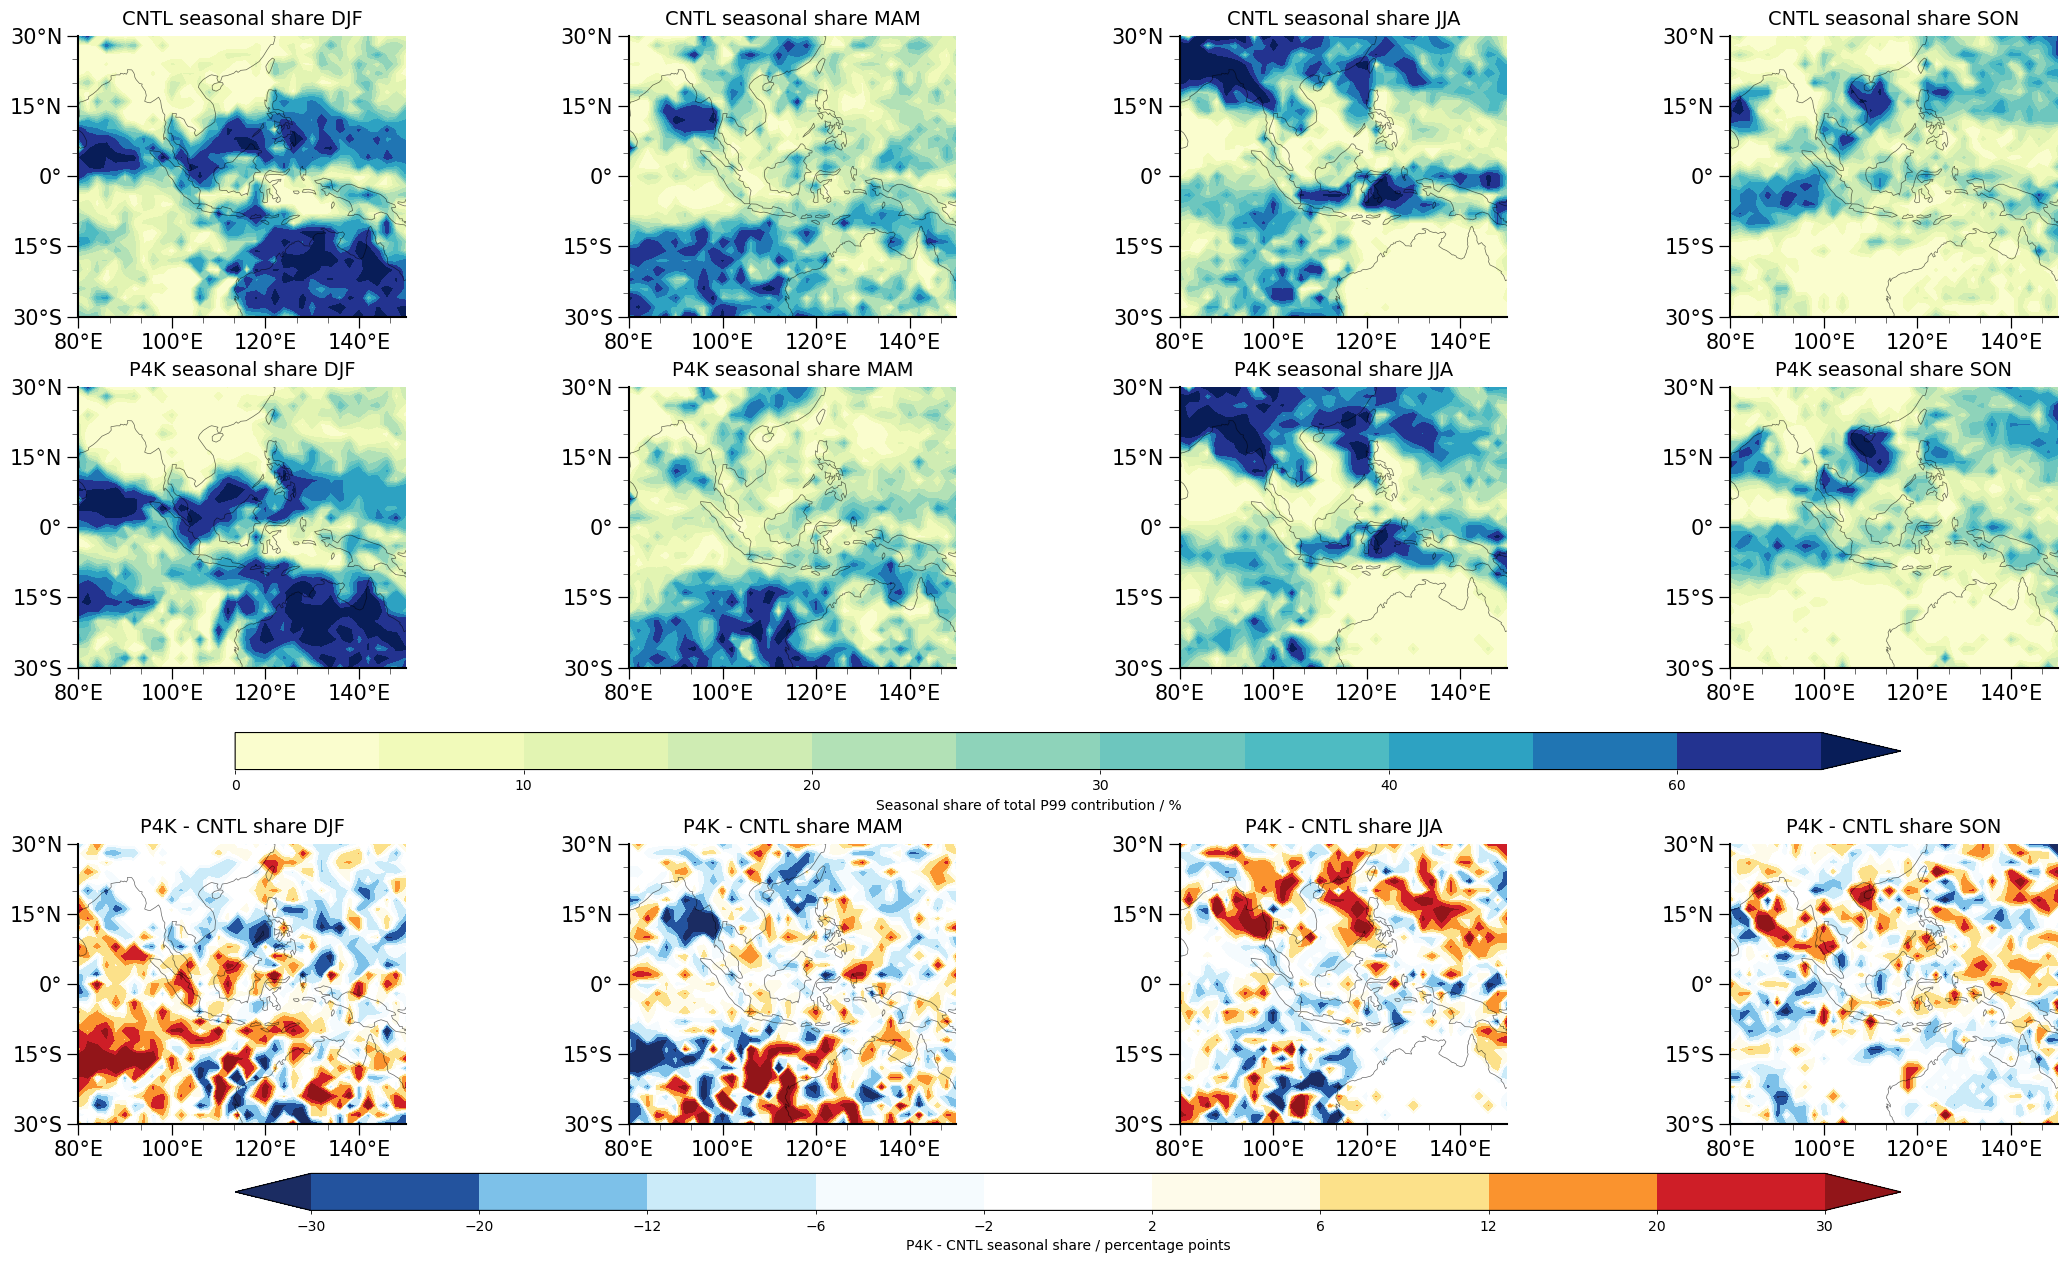

In [12]:
# Seasonal fractional contribution plot
fraction_levels = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 80])
fraction_change_levels = np.array([-30, -20, -12, -6, -2, 2, 6, 12, 20, 30])

fig, axes = plt.subplots(
    3, 4,
    figsize=(22, 12.5),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
    constrained_layout=True,
)

for col, season in enumerate(SEASON_ORDER):
    panel_specs = [
        (p99_contribution_fraction.sel(season=season), 'CNTL seasonal share', fraction_levels, cmaps.MPL_YlGnBu, 'max', 'share'),
        (p99_contribution_fraction_p4k.sel(season=season), 'P4K seasonal share', fraction_levels, cmaps.MPL_YlGnBu, 'max', 'share'),
        (p99_contribution_fraction_change.sel(season=season), 'P4K - CNTL share', fraction_change_levels, cmaps.BlueWhiteOrangeRed, 'both', 'change'),
    ]
    for row, (da, title_prefix, levels, cmap, extend, group) in enumerate(panel_specs):
        ax = axes[row, col]
        _, ax = plot_western_pacific_basemap(
            extent=analysis_extent,
            central_lon=180,
            figsize=(5.5, 4.0),
            title='',
            use_geocat=True,
            show_labels=True,
            add_reference_lines=False,
            land_facecolor='lightgray',
            coastline_color='gray',
            basename='western_pacific_basemap_provided_style',
            save=False,
            fig=fig,
            ax=ax,
        )
        im = ax.contourf(
            da.lon.values,
            da.lat.values,
            da.values,
            levels=levels,
            cmap=cmap,
            transform=ccrs.PlateCarree(),
            extend=extend,
        )
        _turn_off_cartopy_ticks(ax)
        ax.set_title(f'{title_prefix} {season}', pad=8, fontsize=14)
        if group == 'share':
            share_im = im
        else:
            share_change_im = im

cbar_share = fig.colorbar(
    share_im,
    ax=axes[:2, :].ravel().tolist(),
    orientation='horizontal',
    pad=0.04,
    shrink=0.76,
    aspect=45,
    ticks=fraction_levels[::2],
    label='Seasonal share of total P99 contribution / %',
)
cbar_share_change = fig.colorbar(
    share_change_im,
    ax=axes[2, :].ravel().tolist(),
    orientation='horizontal',
    pad=0.04,
    shrink=0.76,
    aspect=45,
    ticks=fraction_change_levels,
    label='P4K - CNTL seasonal share / percentage points',
)
for cbar in (cbar_share, cbar_share_change):
    cbar.ax.tick_params(labelsize=10, length=3, width=0.6)

plt.show()
